![](img/banner.png)
%%HTML
<script src="require.js"></script>

# High Dimensional Data & The Curse of Dimensionality

**Mahmood Amintoosi, Fall 2025**
Computer Science Dept, Ferdowsi University of Mashhad

## Introduction

In modern data mining and machine learning, we often deal with data in very high-dimensional spaces (e.g., images, text embeddings, genomic data). A dataset is typically represented as an $n \times d$ matrix $\mathbf{D}$.

Understanding the nature of high-dimensional space, or **hyperspace**, is very important because it does not behave like the more familiar geometry in two or three dimensions. This phenomenon is often referred to as the **Curse of Dimensionality**.

Key phenomena we will explore:
1.  **Volume Concentration:** The volume of a hypersphere vanishes relative to the hypercube.
2.  **The Problem of Local Neighborhoods:** Why "local" methods like k-NN fail (based on *Elements of Statistical Learning*).
3.  **The Thin Shell:** Most of the volume concentrates near the surface.
4.  **Orthogonality:** Random vectors in high dimensions are nearly orthogonal.
5.  **Gaussian Behavior:** Points concentrate in a thin ring around radius $\sqrt{d}$.

---

## Geometry of Hyperspace: Cubes and Spheres

Let's define the two most basic shapes in $d$-dimensions.

### The Hypercube
The data space is often viewed as a $d$-dimensional hyper-rectangle or hypercube.
For a hypercube $H_d(l)$ with side length $l$, the volume is:

$$\text{Vol}(H_d(l)) = l^d$$

### The Hypersphere
The hypersphere $S_d(r)$ consists of all points exactly at distance $r$ from the center. The volume of a $d$-dimensional hyperball of radius $r$ is given by:

$$\text{Vol}(S_d(r)) = K_d r^d = \frac{\pi^{d/2}}{\Gamma(\frac{d}{2}+1)} r^d$$

Where $\Gamma$ is the Gamma function.

![](img/Figure-6.4-Zaki.png)
Figure 6.4. Hypersphere inscribed inside a hypercube: in (a) two and (b) three dimensions

### The Empty Center (The "Porcupine" Effect)
Consider the space enclosed within the largest hypersphere that can be accommodated within a hypercube of side length $l=2r$.
The ratio of their volumes is:

$$\lim_{d \to \infty} \frac{\text{Vol}(S_d(r))}{\text{Vol}(H_d(2r))} = \lim_{d \to \infty} \frac{\pi^{d/2}}{2^d \Gamma(\frac{d}{2}+1)} \to 0$$

**Implication:** As dimensionality increases, the volume of the hypersphere becomes negligible compared to the hypercube. Most of the volume of the hypercube is in the **corners**, whereas the center is essentially empty.

![Corners in High Dimension](img/Figure-6.5-Zaki.png)

Conceptual view of high-dimensional space: (a) two, (b) three, (c) four, and (d) higher
dimensions. In d dimensions there are $2^d$ “corners” and $2^{d−1}$ diagonals. The radius of the inscribed circle accurately reflects the difference between the volume of the hypercube and the inscribed hypersphere in $d$ dimensions.

---

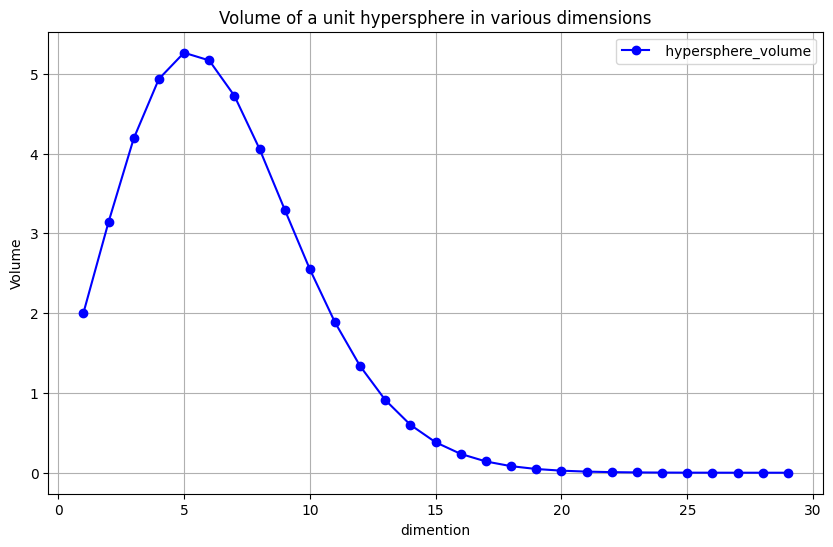

In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np
def hypersphere_volume(d, R):
    volume = (math.pi ** (d / 2)) * (R ** d) / math.gamma(d / 2 + 1)
    return volume
dimensions = range(1, 30)
volumes = [hypersphere_volume(d,1) for d in dimensions]
plt.figure(figsize=(10, 6))
plt.plot(dimensions, volumes, marker='o', linestyle='-', color='b', label=' hypersphere_volume')
plt.xlabel("dimention")
plt.ylabel('Volume')
plt.title("Volume of a unit hypersphere in various dimensions")
plt.legend()
plt.grid(True)
plt.show()


## The Problem of Local Neighborhoods (k-NN)

One of the most significant manifestations of the curse of dimensionality affects "local" methods like k-Nearest Neighbors (k-NN).

### Edge Length of Neighborhoods
Suppose we have inputs uniformly distributed in a $p$-dimensional unit hypercube. We want to form a local neighborhood that captures a fraction $r$ of the observations.
Since this corresponds to a fraction of the unit volume, the expected edge length $e_p(r)$ of this neighborhood is:

$$e_p(r) = r^{1/p}$$

![](img/Figure-2.6-ESL.png)

FIGURE 2.6. The curse of dimensionality is well illustrated by a subcubical
neighborhood for uniform data in a unit cube. The figure on the right shows the
side-length of the subcube needed to capture a fraction r of the volume of the data,
for different dimensions p. In ten dimensions we need to cover 80% of the range
of each coordinate to capture 10% of the data

Let's visualize this for different dimensions ($p$) and fractions ($r$).

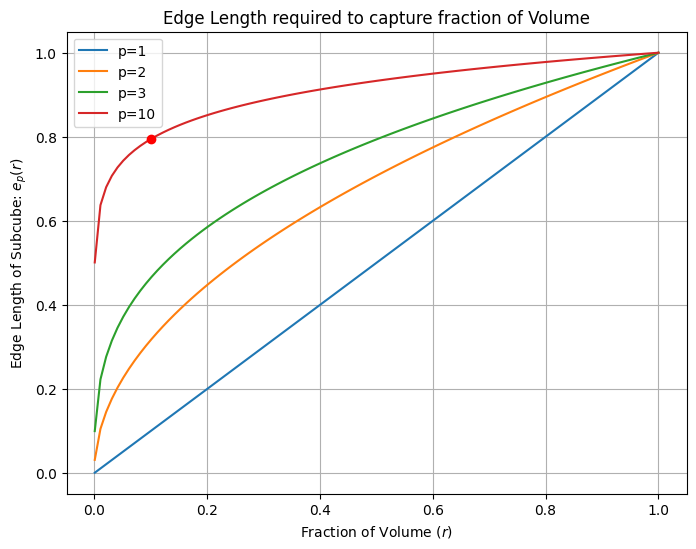

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def edge_length(fraction_volume, p):
    return fraction_volume ** (1/p)

fractions = np.linspace(0.001, 1.0, 100)
dims_esl = [1, 2, 3, 10]

plt.figure(figsize=(8, 6))
for p in dims_esl:
    plt.plot(fractions, edge_length(fractions, p), label=f'p={p}')

# Highlighting the case for p=10, r=0.1
plt.plot(0.1, 0.1**(1/10), 'ro') 

plt.xlabel('Fraction of Volume ($r$)')
plt.ylabel('Edge Length of Subcube: $e_p(r)$')
plt.title('Edge Length required to capture fraction of Volume')
plt.legend()
plt.grid(True)
plt.show()


**Analysis:**
In 10 dimensions ($p=10$), to capture just **10%** ($r=0.1$) of the data, we need to cover **80%** of the range of each input variable.
Such neighborhoods are no longer "local". To find neighbors, we must look very far away.

### Distance to Boundary

Another consequence is that sampling density is sparse. For $N$ data points in a $p$-dimensional unit ball, the median distance from the origin to the closest data point is:

$$ d(p,N) = \left(1 - \frac{1}{2}^{1/N}\right)^{1/p} $$

For $N=500$ and $p=10$, this distance is $\approx 0.52$, which is more than halfway to the boundary. Hence, **most data points are closer to the boundary of the sample space than to any other data point**. This makes prediction a problem of *extrapolation* rather than *interpolation*.

-----


## The Thin Shell Argument

Where is the volume located inside a hypersphere itself?
Consider a thin shell of width $\epsilon$ near the surface of a sphere of radius $r$. The volume of this shell is:

$$ \text{Vol}(S_d(r, \epsilon)) = \text{Vol}(S_d(r)) - \text{Vol}(S_d(r - \epsilon)) $$

![](img/Figure-6.6-Zaki.png)

The ratio of the shell's volume to the total volume is:

$$ \frac{\text{Vol}(S_d(r, \epsilon))}{\text{Vol}(S_d(r))} = 1 - \left( 1 - \frac{\epsilon}{r} \right)^d $$

As $d \to \infty$, the term $(1 - \frac{\epsilon}{r})^d$ tends to 0.

$$ \lim_{d \to \infty} \frac{\text{Vol}(S_d(r, \epsilon))}{\text{Vol}(S_d(r))} \to 1 $$

> For example, for a circle in two dimensions, with r =1 and $\epsilon$ = 0.01 the
volume of the thin shell is $1−(0.99)^2 = 0.0199 ≃ 2%$. As expected, in two-dimensions,
the thin shell encloses only a small fraction of the volume of the original hypersphere.
But for 100 dimensions thin shell volume becomes $1−(0.99)^{100} ≃ 1 - 0.37 ≃ 0.63$.

**Conclusion:** In high dimensions, almost **100% of the volume** (and probability mass) of a hypersphere is concentrated in a thin shell near the surface (crust). The interior is essentially empty.

-----

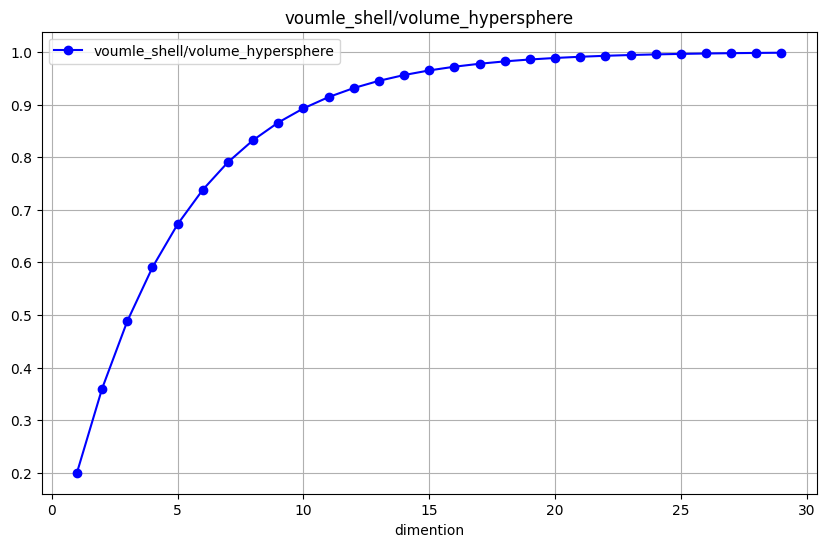

In [12]:
def shell_volume(d,R,e):
    volume = hypersphere_volume(d,R) - hypersphere_volume(d,R-e)
    return volume

v = []
for d in range(1,30):
    v.append(shell_volume(d,1,0.2)/hypersphere_volume(d,1))
plt.figure(figsize=(10, 6))
plt.plot(dimensions, v, marker='o', linestyle='-', color='b', label='voumle_shell/volume_hypersphere')
plt.xlabel('dimention')
plt.ylabel('')
plt.title("voumle_shell/volume_hypersphere")
plt.legend()
plt.grid(True)
plt.show()

## Generating Uniform Points on a Hypersphere

Generating points uniformly inside a hypersphere in high dimensions is tricky.
Due to the volume properties discussed above, simple methods like "Rejection Sampling" (generate in cube, keep if in sphere) fail because the acceptance rate approaches zero (remember the Empty Center/Porcupine effect).

 **Rejection Sampling:** Generate points in a Hypercube and keep those inside the Sphere.

 *Problem:* As we proved in Section 1, the ratio of sphere volume to cube volume goes to 0. You will reject almost 100% of your points. This is computationally infeasible.

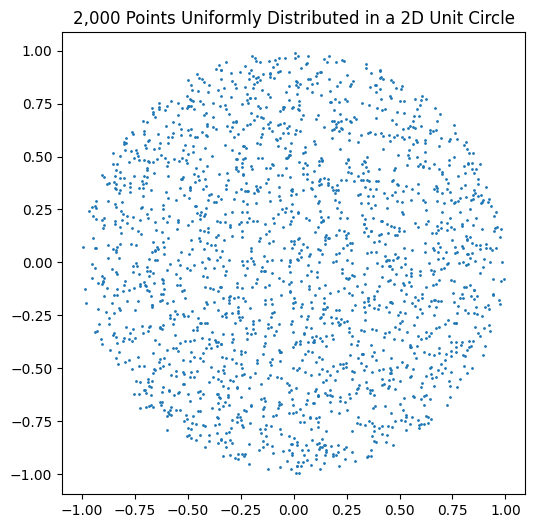

Dimension: 2, Total points generated: 2574, Ratio: 0.777000777000777
Dimension: 3, Total points generated: 3766, Ratio: 0.5310674455655868
Dimension: 4, Total points generated: 6580, Ratio: 0.303951367781155
Dimension: 5, Total points generated: 11398, Ratio: 0.1754693805930865
Dimension: 6, Total points generated: 23695, Ratio: 0.0844059928254906
Dimension: 7, Total points generated: 53522, Ratio: 0.037367811367288215
Dimension: 8, Total points generated: 123644, Ratio: 0.016175471514994662
Dimension: 9, Total points generated: 310177, Ratio: 0.0064479313424270655
Dimension: 10, Total points generated: 807321, Ratio: 0.0024773293398784374


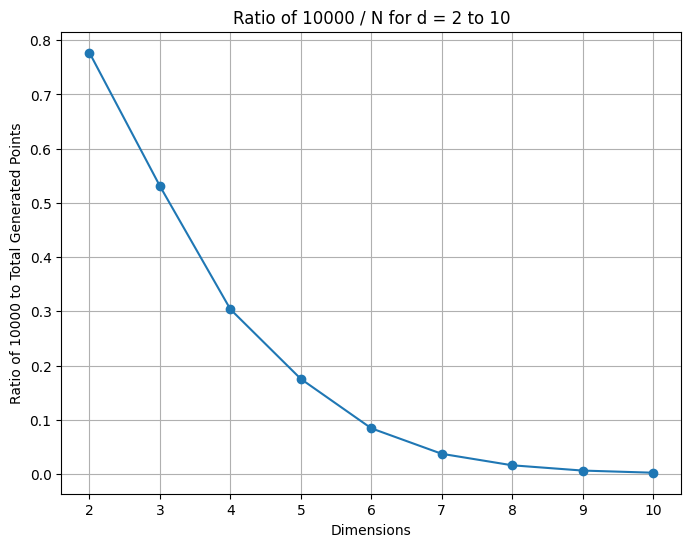

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate num_points points uniformly inside a d-dimensional unit sphere
def generate_points_in_unit_sphere(num_points, d):
    points_inside = []
    total_generated_points = 0  # To track the total number of points generated
    batch_size = num_points  # Initial batch size for generating points
    
    while len(points_inside) < num_points:
        # Generate batch_size points uniformly in the d-dimensional hypercube
        points = np.random.uniform(-1, 1, (batch_size, d))
        
        # Calculate the Euclidean distance of each point from the origin
        distances = np.sum(points**2, axis=1)
        
        # Select points that lie inside the unit sphere
        inside_sphere = points[distances <= 1]
        
        # Append the points inside the sphere to the list
        points_inside.extend(inside_sphere)
        
        # Count total generated points
        total_generated_points += len(points)
        
        # Adjust batch size if we're close to the desired number of points
        remaining_points = num_points - len(points_inside)
        if remaining_points < batch_size:
            batch_size = remaining_points
    
    # Convert the list to a numpy array for efficient storage and manipulation
    points_inside = np.array(points_inside[:num_points])
    
    # Calculate the ratio 2000 / N where N is total_generated_points
    ratio = num_points / total_generated_points
    
    # Return the points inside the sphere and the ratio
    return points_inside, total_generated_points, ratio

# Visualize 2D case
def visualize_2D(points):
    plt.figure(figsize=(6, 6))
    plt.scatter(points[:, 0], points[:, 1], s=1)
    plt.title('2,000 Points Uniformly Distributed in a 2D Unit Circle')
    plt.gca().set_aspect('equal')
    plt.show()

# Generate and visualize points in various dimensions
num_points = 2000
dimensions = list(range(2, 11))  # d from 2 to 10
ratios = []  # To store the ratios for different dimensions

for d in dimensions:
    points_inside, total_generated_points, ratio = generate_points_in_unit_sphere(num_points, d)
    ratios.append(ratio)
    
    if d == 2:
        # For 2D case, visualize the points
        visualize_2D(points_inside)
    
    print(f"Dimension: {d}, Total points generated: {total_generated_points}, Ratio: {ratio}")

# Plot the ratios for dimensions from 2 to 10
plt.figure(figsize=(8, 6))
plt.plot(dimensions, ratios, marker='o')
plt.title('Ratio of 10000 / N for d = 2 to 10')
plt.xlabel('Dimensions')
plt.ylabel('Ratio of 10000 to Total Generated Points')
plt.grid(True)
plt.show()



**Generate points form Gaussian distribution**

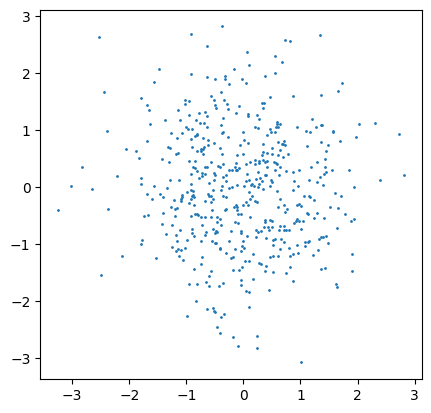

In [29]:
n_points = 500
d = 2
x = np.random.randn(n_points, d)
plt.scatter(x[:,0],x[:,1],1)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.draw()


### Random vector uniformly distributed on the surface of a unit hypersphere

To generate a random vector $\mathbf{y}$ uniformly distributed on the surface of a unit hypersphere $S_d(1)$:

1.  Generate $x_i \sim \mathcal{N}(0, 1)$ for $i=1 \dots d$.
2.  Normalize: $\mathbf{y} = \frac{\mathbf{x}}{||\mathbf{x}||}$.

This works because the multivariate Gaussian is spherically symmetric.


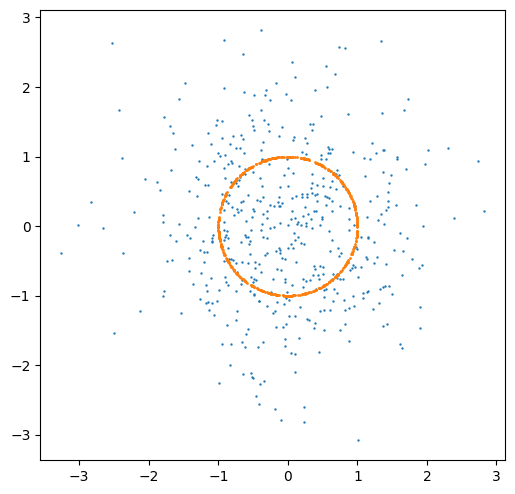

In [39]:
norm_x = np.linalg.norm(x, axis=1)
y = x/norm_x[:,np.newaxis]
plt.figure(figsize=(6, 6))
plt.scatter(x[:,0],x[:,1],.5)
plt.scatter(y[:,0],y[:,1],1)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.draw()

The joint probability density of the independent Gaussian components is spherically symmetric:

$$ f(x) = \prod_{i=1}^d \frac{1}{\sqrt{2\pi}} e^{-x_i^2/2} = \frac{1}{(2\pi)^{d/2}} e^{-\frac{1}{2}\sum x_i^2} = \frac{1}{(2\pi)^{d/2}} e^{-\frac{||x||^2}{2}} $$

Since the density depends only on the length $||x||$ and not the direction, the direction vectors are uniformly distributed.

**Conclusion:**
The density function $f(\mathbf{x})$ depends **only on the length** (magnitude) of the vector $||\mathbf{x}||$, and not on its coordinates (direction).
* This property is called **Spherical Symmetry** or **Isotropy**.
* It implies that the distribution is invariant under rotation. Therefore, all directions are equally probable, and the normalized vector $\mathbf{y} = \mathbf{x} / ||\mathbf{x}||$ is uniformly distributed on the hypersphere.


### Generating Points *Inside* the Ball

If we want points uniformly distributed *inside* the ball (not just on the surface), simply scaling by a uniform random number $\rho \in [0,1]$ is incorrect because it bunches points near the center (volume is smaller there).

$$y=\rho\frac{x}{||x||}, \quad 0\le \rho \le 1$$

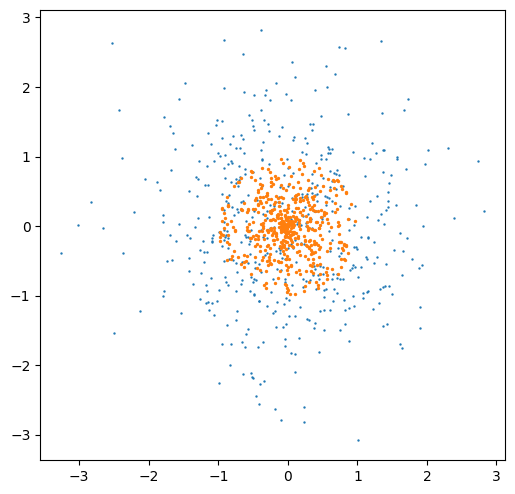

In [37]:
rho = np.random.rand(len(x))
y = rho[:,np.newaxis] * x/norm_x[:,np.newaxis]
plt.figure(figsize=(6, 6))
plt.scatter(x[:,0],x[:,1],.5)
plt.scatter(y[:,0],y[:,1],2)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.draw()

**Why is the naive approach incorrect?**  
If we simply sample the radius $\rho$ uniformly from $[0,1]$, the generated points will cluster near the center.  
In $d$ dimensions, the volume of a thin shell at radius $r$ grows proportionally to $r^{d-1}$.  
This means there is far more volume near the surface ($r \approx 1$) than near the center ($r \approx 0$).  
To achieve a truly uniform distribution inside the ball, the probability of a point lying within radius $r$ must be proportional to the volume enclosed by that radius.

> For uniform volume density, the cumulative distribution function (CDF) must follow the volume growth $r^d$.  
> Thus, we require the random variable $R$ (the radius) to satisfy: $P(R \le r) = r^d.$
> Using Inverse Transform Sampling with $a \sim U(0,1)$, we obtain:  $R = a^{1/d}.$
> A particular sample of $R$ will be denoted by $\rho$.

---

### 1. Determining the Target CDF
Let $R$ denote the random variable representing the radius of a point.  
The cumulative distribution function (CDF), $F(r)$, gives the probability that a point lies within radius $r$:

$$F(r) = P(R \le r).$$

For a uniform distribution inside the $d$‑ball, this probability equals the ratio of the volume of the ball of radius $r$ to the total volume (radius 1):

$$F(r) = \frac{\text{Vol}(S_d(r))}{\text{Vol}(S_d(1))} 
      = \frac{K_d r^d}{K_d \cdot 1^d} 
      = r^d.$$

So our target CDF is simply:

$$F(r) = r^d.$$

---

### 2. Inverse Transform Sampling
How do we generate random radii that follow $F(r) = r^d$?  
We use the **Inverse Transform Sampling** method:

- If $a \sim \mathcal{U}(0,1)$ and $F$ is a continuous CDF, then $X = F^{-1}(a)$ has distribution $F$.  
- Intuitively: we draw a random probability $a$ from $[0,1]$, and ask: *“Which radius $r$ corresponds to this cumulative probability?”*  
- Formally:  If $a \sim U(0,1)$, then $X = F^{-1}(a)$ has distribution $F$:

$$P(X \le R) = P(F^{-1}(a) \le R) = P(a \le F(R)) = F(R).$$

Therefore, if $a \sim \mathcal{U}(0,1)$, then:

$$R = F^{-1}(a) = a^{1/d}.$$

And when we actually generate a sample, we denote it by:

$$\rho = a^{1/d}.$$

---

### 3. Example (for $d=2$)
For a 2‑dimensional ball (a disk), we have:

$$\rho = \sqrt{a}.$$

| $a \sim \mathcal{U}(0,1)$ | $\rho = \sqrt{a}$ |
|--------------------------|---------------------|
| 0.00                     | 0.000               |
| 0.10                     | 0.316               |
| 0.25                     | 0.500               |
| 0.50                     | 0.707               |
| 0.75                     | 0.866               |
| 1.00                     | 1.000               |

This table shows how the transformation spreads points more evenly across the disk, avoiding clustering near the center.

---

### 4. Application to the Hypersphere
Applying this to our radius variable $R$:

1. Generate a uniform random number $a \sim \mathcal{U}(0,1)$.  
2. Compute the radius sample: $\rho = a^{1/d}$.  
3. Combine with a random direction to obtain a point inside the ball.

---

### Algorithm for Uniform Points in a $d$‑Ball
1. Generate a random vector $\mathbf{x} \sim \mathcal{N}(0, I_d)$.  
2. Normalize: $\mathbf{y} = \mathbf{x} / \|\mathbf{x}\|$ (this gives a random direction on the unit sphere).  
3. Generate $a \sim \mathcal{U}(0,1)$.  
4. Scale: $\mathbf{z} = (a^{1/d}) \mathbf{y}$ (this places the point uniformly inside the ball).  


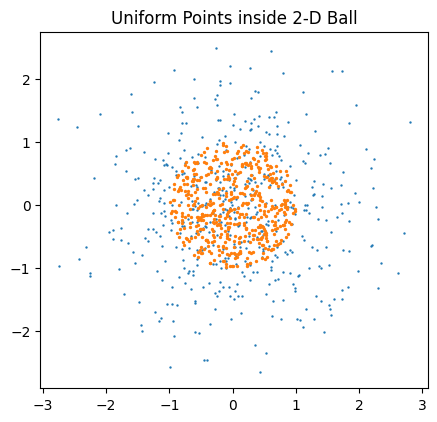

In [10]:
# Generate uniform points in 2D circle for visualization
n_points = 500
d = 2

# 1. Direction (Muller Method)
x = np.random.randn(n_points, d)
norm_x = np.linalg.norm(x, axis=1)
y_surface = x / norm_x[:, np.newaxis]

# Correct radial scaling
a = np.random.rand(n_points)
rho = a**(1/d)
y_inside = rho[:, np.newaxis] * y_surface

plt.figure(figsize=(5, 5))
# plt.scatter(y_inside[:,0], y_inside[:,1], s=2)
plt.scatter(x[:,0],x[:,1],.5)
plt.scatter(y_inside[:,0],y_inside[:,1],2)
plt.gca().set_aspect('equal')
plt.title(f"Uniform Points inside {d}-D Ball")
plt.show()


-----

Another counter-intuitive property is that "every direction is orthogonal to every other direction." or random vectors in high dimensions are nearly orthogonal to each other.

### Random Vectors

Consider the diagonal vector in a hypercube $\mathbf{1} = (1, 1, \dots, 1)^T$. The angle $\theta_d$ between this diagonal and any coordinate axis $\mathbf{e}_1 = (1, 0, \dots, 0)^T$ is:

$$ \cos \theta_d = \frac{\mathbf{e}_1^T \mathbf{1}}{||\mathbf{e}_1|| \cdot ||\mathbf{1}||} = \frac{1}{1 \cdot \sqrt{d}} = \frac{1}{\sqrt{d}} $$

As $d \to \infty$, $\cos \theta_d \to 0$, which means $\theta_d \to 90^\circ$. The diagonal is effectively orthogonal to the axes\!

Furthermore, **random vectors** in high dimensions are nearly orthogonal to each other.

In [6]:
dim = 200
# Generate random vectors
x = np.random.randn(4, dim)
# Normalize
x_norm = x / np.linalg.norm(x, axis=1)[:, np.newaxis]

print(f"Dot products of random pairs in {dim}-D:")
for i in range(len(x_norm)):
    for j in range(i+1, len(x_norm)):
        dp = np.dot(x_norm[i], x_norm[j])
        print(f"Vector {i} . Vector {j} = {dp:.4f}")

Dot products of random pairs in 200-D:
Vector 0 . Vector 1 = -0.0345
Vector 0 . Vector 2 = 0.0655
Vector 0 . Vector 3 = 0.0054
Vector 1 . Vector 2 = -0.0890
Vector 1 . Vector 3 = -0.0445
Vector 2 . Vector 3 = 0.0598



## Gaussian Distribution in High Dimensions

### From Geometric Thin Shells to Statistical Thin Shells

In previous sections, we saw several geometric phenomena:

* The **Empty Center / Porcupine Effect** in hypercubes
* The **Thin Shell** inside hyperspheres
* How uniform sampling becomes concentrated near the **surface** rather than the **center**

We also generated uniform points *on* and *inside* a hypersphere and observed that the **volume grows outward**, causing most points to stay away from the center.

Now we show that **Gaussian data behave in exactly the same way** — even though the Gaussian distribution is centered at the origin.

---

## Why Gaussian Points Do *Not* Cluster Near the Mean (Unlike 1D)

Let
$ x = (x_1,\dots,x_d) \sim \mathcal{N}(0, I_d) $.

In one dimension, many sampled points lie “close to zero,” and the distance $|x|$ is usually small.
However, this intuition **completely breaks down** as soon as we move to dimension 2 or higher.

The key difference is **geometry**:

* In 1D, “the center” is just a point, and the line has no notion of volume growth.
* In higher dimensions, **volume explodes with radius**:

  * Area $\propto r^2$
  * Volume $\propto r^3$
  * In general: hypersphere volume $\propto r^{d}$

Thus, although the Gaussian **density** is highest at the origin, the **available volume** near the origin is vanishingly small.

> **The center has the highest density but almost zero volume ⇒ almost no sampled points appear there.**

This exactly mirrors the thin-shell phenomenon you observed for uniform sampling.

---

## Distance of a Gaussian Vector from the Origin

A central identity explains the behavior:

$$|x|^2 = \sum_{i=1}^d x_i^2 \sim \chi^2_d$$

Thus (See [Chi-squared distribution](https://en.wikipedia.org/wiki/Chi-squared_distribution)):

$$\mathbb{E}[|x|^2] = d \qquad\Rightarrow\qquad \mathbb{E}[|x|] \approx \sqrt{d}.$$

* In 1D: $|x| \approx 0.8$ (close to the center)
* In 2D: $|x| \approx \sqrt{2} \approx 1.41$
* In 10D: $|x| \approx \sqrt{10} \approx 3.16$
* In 200D: $|x| \approx \sqrt{200} \approx 14.1$

And importantly:

> **Increasing dimension pushes *all* Gaussian samples outward, not just a few outliers.
> Almost the entire distribution lies in a thin spherical shell around radius $\sqrt{d}$.**

This is the statistical analogue of the geometric thin-shell effect.

---

## Numerical Simulation: Gaussian Thin Shell

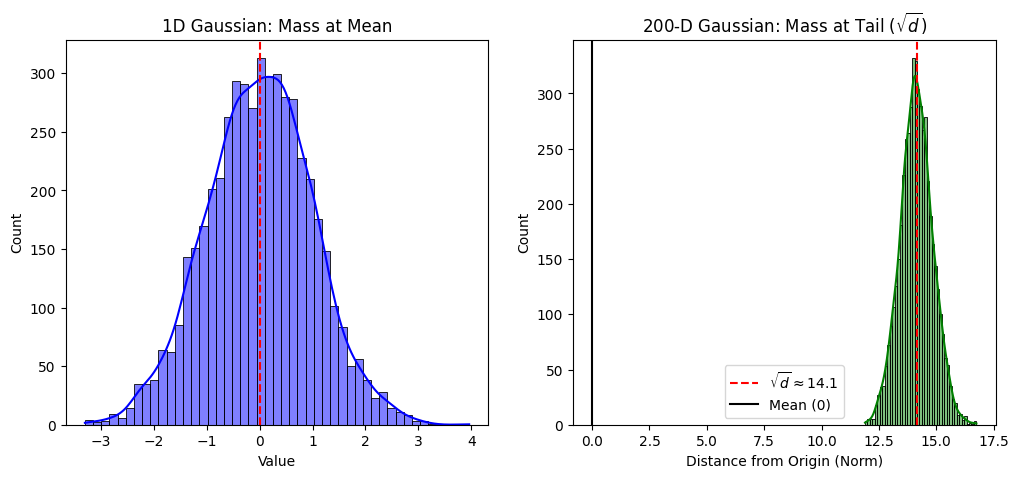

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simulation: 1D vs High-D Gaussian
d = 200
n_samples = 5000

# 1D Gaussian
x_1d = np.random.randn(n_samples)

# High-D Gaussian
x_high = np.random.randn(n_samples, d)
norm_x_high = np.linalg.norm(x_high, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: 1D behavior
sns.histplot(x_1d, kde=True, ax=ax[0], color='blue')
ax[0].set_title("1D Gaussian: Mass at Mean")
ax[0].set_xlabel("Value")
ax[0].axvline(0, color='red', linestyle='--', label='Mean (0)')

# Plot 2: High-D behavior
sns.histplot(norm_x_high, kde=True, ax=ax[1], color='green')
ax[1].set_title(f"{d}-D Gaussian: Mass at Tail ($\sqrt{{d}}$)")
ax[1].set_xlabel("Distance from Origin (Norm)")
ax[1].axvline(np.sqrt(d), color='red', linestyle='--', label='$\sqrt{d} \\approx 14.1$')
ax[1].axvline(0, color='black', linestyle='-', label='Mean (0)')

plt.legend()
plt.show()

These two plots illustrate the fundamental shift from “mass at center” (low dimension) to “mass in a thin shell” (high dimension).

---

## The Gaussian Annulus Phenomenon

A formal version states:

> With overwhelming probability, a Gaussian sample lies inside
> $ \sqrt{d} \pm O(1) $
> — a thin annulus whose thickness does *not* grow with $d$.

As $d$ increases:

* Radius grows like $\sqrt{d}$
* Shell thickness remains constant
* Relative shell thickness → 0

So the Gaussian distribution becomes **extremely concentrated** on a thin spherical layer.

This mirrors exactly what we saw earlier for:

* Uniform points inside a hypersphere
* Rejection sampling
* Volume concentration
* Empty Center effect

This is why Gaussian distributions are used so heavily in theory:
they reflect the **intrinsic geometry of high-dimensional space**.

---

## Connection to Previous Sections

Here is how the Gaussian phenomenon links back to the concepts earlier in the notebook:

**Relation to “Empty Center / Porcupine Effect”**

Volume around the center is negligible in high dimensions →
**Gaussian mass avoids the center**, exactly like uniform points.

---

**Relation to “Thin Shell Argument”**

Uniform hypersphere volume concentrates at radius $r$:
Gaussian probability mass concentrates at radius $\sqrt{d}$.
The geometry is identical; only the radius scale differs.

---

**Relation to “Generating Points Inside the Ball”**

You observed that uniform points require special sampling ($\rho = a^{1/d}$)
because naive sampling bunches points near the center.

Gaussian sampling naturally avoids the center due to the same volume effects.

---

**Relation to “Random Vectors are Nearly Orthogonal”**

Since nearly all Gaussian points lie at distance $\sqrt{d}$,
their normalized directions behave almost like points uniformly distributed on the sphere.

Thus Gaussian vectors are almost orthogonal —
the basis for **random projection** and **Johnson–Lindenstrauss**.

---

## Why This Matters (Preparing for JL)

Gaussian thin-shell concentration ensures:

* Pairwise distances are stable
* Dot products are small
* Random projections preserve geometry

These facts are exactly what the **Johnson–Lindenstrauss Lemma** formalizes.

This section therefore serves as the **bridge** from geometric properties of high-dimensional space to the theoretical foundation of dimensionality reduction.



### Summary

  * High-dimensional space is **empty** in the center.
  * Volume is in the **corners** or a **thin shell** at the surface.
  * **Neighbors** are far away (breaking local methods like k-NN).
  * Random vectors are **orthogonal**.

### References

1.  Zaki, M. J., & Meira Jr, W. (2014). *Data Mining and Machine Learning: Fundamental Concepts and Algorithms*. Cambridge University Press. (Chapter 6).
2.  Blum, A., Hopcroft, J., & Kannan, R. (2020). *Foundations of Data Science*. Cambridge University Press.
3.  Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*.
